# Reduciendo el tamaño del modelo

Se realizan variaciones del modelo construido en 3.4 y se analiza su rendimiento. En particular se estudia la reduccion de tamaño de un modelo para evitar el overfiting y sus efectos en el poder de generalización.

# Data y preprocesing

Antes que nada hay que considerar la recuperación de los datos y su preprocesado.

In [1]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
num_words=10000)

2025-07-21 18:22:17.619117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753132938.160946  530586 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753132938.451186  530586 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753132940.484732  530586 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753132940.484811  530586 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753132940.484819  530586 computation_placer.cc:177] computation placer alr

In [2]:
import numpy as np

"""Vectoriza un un conjunto de conjuntos de datos numericos en codificación ONE-HOT.
Persiste la información del contenido de cada conjunto pero se pierde todo lo relacionado
al orden y la cantidad de veces que aparece cada valor.

Keyword arguments:
sequences -- Conjunto de conjuntos de valores numericos.
dimension -- (def=10000) Cantidad de dimenciones a considerar para el tamaño de cada 
vectorizacion ONE-HOT.
Return: Conjunto de Conjuntos Vectorizado ONE-HOT
"""
def vectorize_sequences(sequences, dimension=10000):
    result = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        result[i, sequence] = 1
    return result
        
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [3]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# Comparacion de modelos

En este conjunto de celdas se realiza la construccion, entrenamiento y evaluación de la misma arquitectura pero variando la *capacidad* (cantidad de parametros entrenables en cada capa). Al final se muestran graficos comparando su *acc* y *loss* en el conjunto de validación a lo largo de las etapas que entreno.

In [7]:
from tensorflow.keras import models
from tensorflow.keras import layers

# Tamaños de modelo con los que realizar pruebas
sizes = [4, 16, 512]
historys = []
for size in sizes:
    model = models.Sequential()
    model.add(layers.Dense(size, activation='relu', input_shape=(10000,)))
    model.add(layers.Dense(size, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

    history = model.fit(
        partial_x_train,
        partial_y_train,
        epochs=20,
        batch_size=512,
        validation_data=(x_val, y_val))
    historys.append(history)

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - acc: 0.6470 - loss: 0.6530 - val_acc: 0.8419 - val_loss: 0.5428
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.8566 - loss: 0.4957 - val_acc: 0.8660 - val_loss: 0.4286
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8943 - loss: 0.3808 - val_acc: 0.8640 - val_loss: 0.3706
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9078 - loss: 0.3115 - val_acc: 0.8717 - val_loss: 0.3335
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9226 - loss: 0.2624 - val_acc: 0.8826 - val_loss: 0.3047
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9313 - loss: 0.2276 - val_acc: 0.8911 - val_loss: 0.2845
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9417 - loss: 0.1945 - val_acc: 0.8906 - val_loss: 0.2766
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9466 - loss: 0.1743 - val_acc: 0.8900 - val_loss: 0.2750
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9529

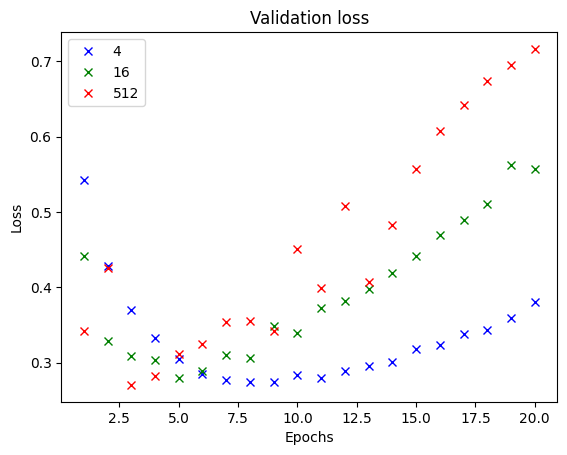

In [9]:
import matplotlib.pyplot as plt

colors = ["blue", "green", "red"]

for history, color, size in zip(historys, colors, sizes):
    val_loss_values = history.history['val_loss']

    epochs = range(1, len(val_loss_values) + 1)

    plt.plot(epochs, val_loss_values, 'x', label=str(size), color=color)

plt.title('Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

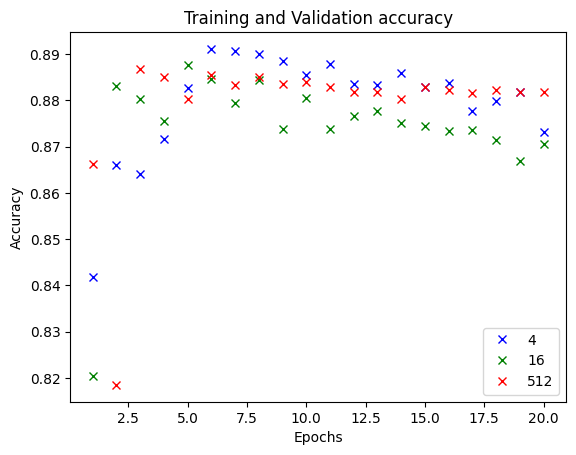

In [11]:
import matplotlib.pyplot as plt

for history, color, size in zip(historys, colors, sizes):
    val_acc_values = history.history['val_acc']

    epochs = range(1, len(val_acc_values) + 1)

    plt.plot(epochs, val_acc_values, 'x', label=str(size), color=color)

plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

La correlación entre *capacidad* y velocidad de *overfitting* es observable. No solo empieza mas temprano sino que su pendiente es mas pronunciada.